## BBC News Classification Kaggle Mini-Project


## Brief description of the problem and data 

In this mini-project, we shall build a machine learning model that predicts which Tweets are about real disasters and which one’s aren’t. We shall have access to a dataset of 10,000 tweets that were hand-classified apriori, hence contain groud-truth labels. We shall use a **binary text classification model** which will be trained on these tweets and then later will be used to predict the class labels for an unseen test data.

Given a train and a test csv file, where each sample in the train and test set has the following information:

* The text of a tweet
* A keyword from that tweet (although this may be blank!)
* The location the tweet was sent from (may also be blank)

We shall predict whether a given tweet is about a real disaster or not. If so, predict a 1. If not, predict a 0.

Twitter has become an important communication channel in times of emergency. The ubiquitousness of smartphones enables people to announce an emergency they’re observing in real-time. Because of this, more agencies are interested in programatically monitoring Twitter (i.e. disaster relief organizations and news agencies). But, it’s not always clear whether a person’s words are actually announcing a disaster. That's where the classifier will be useful.

## Exploratory Data Analysis (EDA) — Inspect, Visualize and Clean the Data 

First we need to import all `python` packages / functions (need to install with `pip` if some of them are not already installed) that are required to the clean the texts (from the tweets), for building the RNN models and for visualization. We shall use `tensorflow / keras` to to train the deep learning models. 

In [ ]:
import numpy as np 
import pandas as pd 
import os, math

#for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

#for text cleaning / preprocessing
import string, re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

#for data analysis and modeling
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.preprocessing import text, sequence 
from tensorflow.keras.layers import Dropout
from tensorflow.keras.metrics import Recall
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Embedding, Dropout
tf.__version__
# 2.12.0

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Read the train and test dataframe, the only columns that we shall use are *text* (to extract input features) and *target* (output to predict).

In [151]:
df_train = pd.read_csv('learn-ai-bbc/BBC News Train.csv') #, index_col='id')
df_test = pd.read_csv('learn-ai-bbc/BBC News Test.csv') #, index_col='id')
df_train.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [6]:
df_test.head()

,ArticleId,Text
0,1018,qpr keeper day heads for preston queens park r...
1,1319,software watching while you work software that...
2,1138,d arcy injury adds to ireland woe gordon d arc...
3,459,india s reliance family feud heats up the ongo...
4,1020,boro suffer morrison injury blow middlesbrough...


There around 7.6k tweets in the training and 3.2k tweets in the test dataset, respectively.

In [7]:
df_train.shape, df_test.shape

((1490, 3), (735, 2))

Maximum number of words present in a tweet is 31, for both training and test dataset

In [9]:
max_len_train = max(df_train['Text'].apply(lambda x: len(x.split())).values)
max_len_test = max(df_train['Text'].apply(lambda x: len(x.split())).values)
max_len_train, max_len_test

(3345, 3345)

The following plot shows histogram of class labels, the number of positive (disaster) and negative (no distaster) classes in the training dataset. As can be seen, the dataset is slightly imbalanced.

5


,Category,count
0,sport,346
1,business,336
2,politics,274
3,entertainment,273
4,tech,261


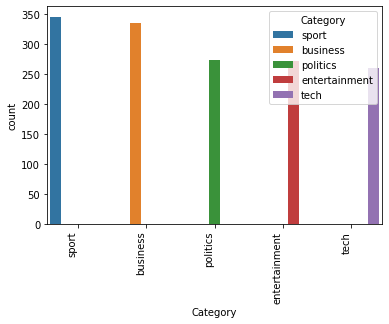

In [71]:
freq_df = pd.DataFrame(df_train['Category'].value_counts()).reset_index()
freq_df.columns = ['Category', 'count']
ncats = len(freq_df)
print(ncats)
ax = sns.barplot(data=freq_df, x='Category', y='count', hue='Category')
ax.set_xticklabels(ax.get_xticklabels(), 
                          rotation=90, 
                          horizontalalignment='right')
plt.margins(x=0.01)
freq_df.head()

## Preprocessing / Cleaning

Since the tweet texts are likely to contain many junk characters, very common non-informative words (*stopwords*, e.g., 'the'), it is a good idea to clean the text (with the function `clean_text()` as shown below) and remove unnecessary stuffs before building the models, otherwise they can affect the performance. It's important that we apply the same preprocessing on both the training and test tweets.

In [58]:
def clean_text(txt):
    """""
    cleans the input text by following the steps:
    * replace contractions
    * remove punctuation
    * split into words
    * remove stopwords
    * remove leftover punctuations
    """""
    
    #remove punctuations
    txt  = "".join([char for char in txt if char not in string.punctuation])
    #remove numbers
    txt = re.sub('[0-9]+', '', txt)
    txt = txt.lower() # lowercase
    
    # split into words
    words = word_tokenize(txt)
    
    # remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if not w in stop_words]
    
    # removing leftover punctuations
    words = [word for word in words if word.isalpha()]
    
    cleaned_text = ' '.join(words)
    return cleaned_text

# clean train and test tweets
df_train['Text'] = df_train['Text'].apply(lambda txt: clean_text(txt))
df_test['Text'] = df_test['Text'].apply(lambda txt: clean_text(txt))

df_train.head()

,ArticleId,Text,Category
0,1833,worldcom exboss launches defence lawyers defen...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens maj...,business
3,1976,lifestyle governs mobile choice faster better ...,tech
4,917,enron bosses payout eighteen former enron dire...,business


Now, let's use the wordcloud library to find the most frequent words in disaster tweets and normal tweets. As we can see, 

* the top 10 most frequent words in disaster tweets (with class label 1) are: 'fire', 'New', 'via', 'disaster', 'California', 'suicide', 'U', 'police', 'amp', 'people'
* the top 10 most frequent words in the normal tweets (with class label 0) are: 'new', 'amp', 'u', 'one', 'body', 'time', 'video', 'via', 'day', 'love'

category business, top 10 words: ['said', 'year', 'u', 'mr', 'bn', 'firm', 'new', 'market', 'sale', 'growth']


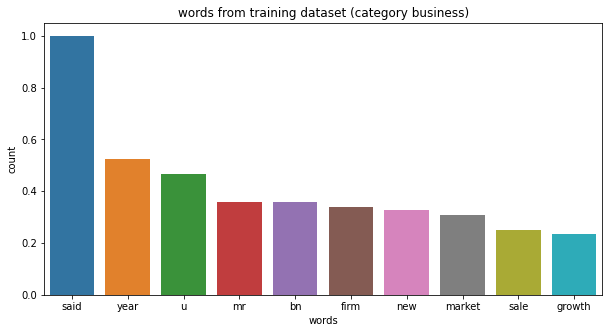

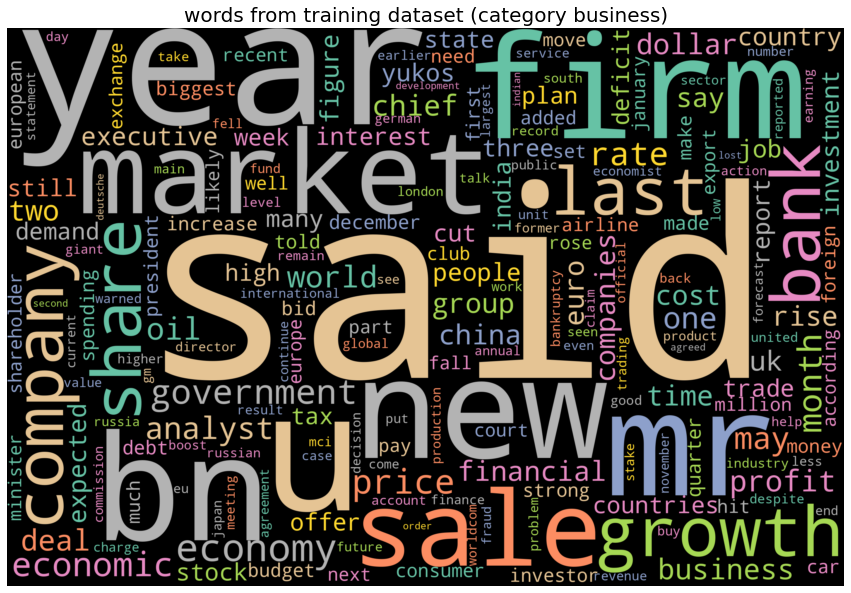

category tech, top 10 words: ['said', 'people', 'new', 'mobile', 'phone', 'game', 'service', 'mr', 'year', 'one']


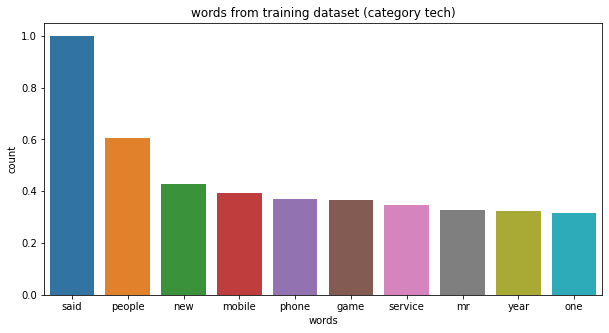

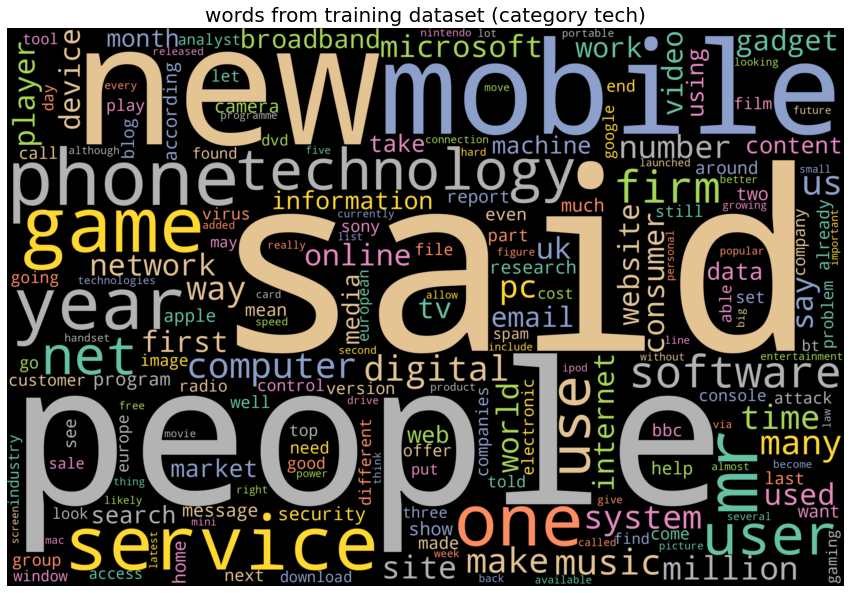

category politics, top 10 words: ['said', 'mr', 'labour', 'government', 'election', 'blair', 'people', 'minister', 'party', 'new']


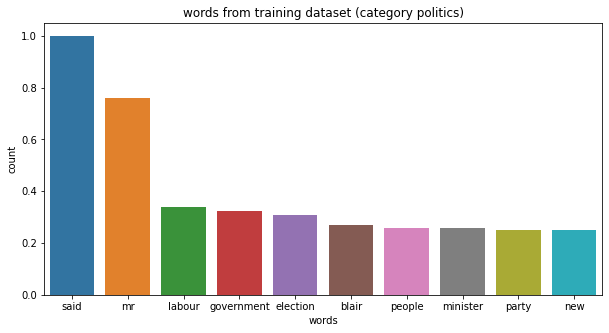

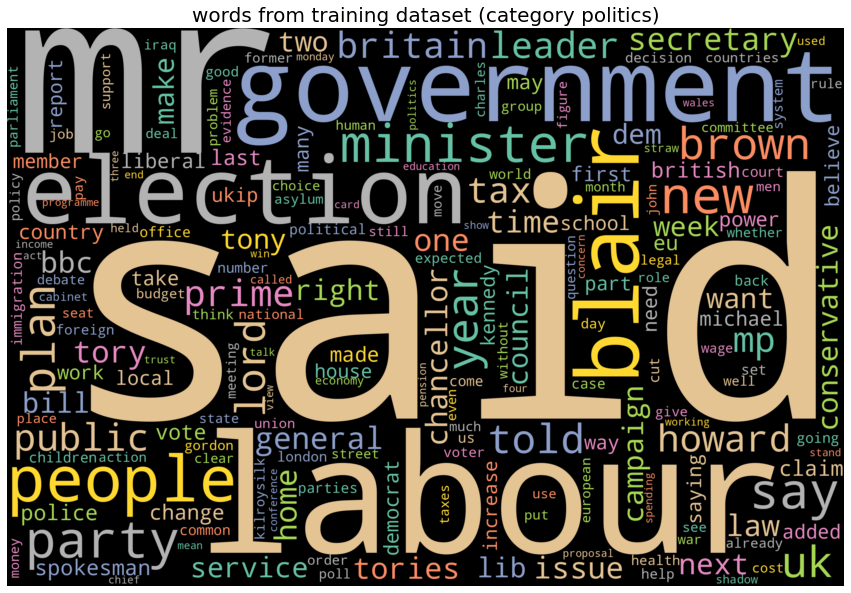

category sport, top 10 words: ['said', 'game', 'win', 'england', 'first', 'player', 'year', 'world', 'time', 'last']


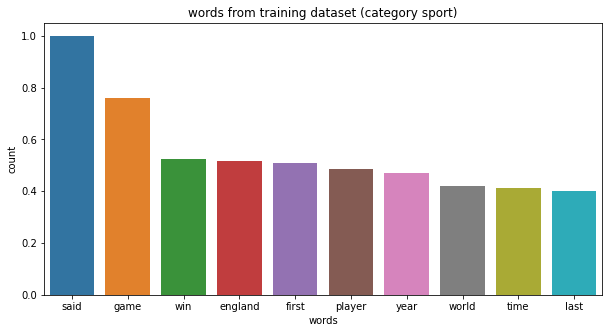

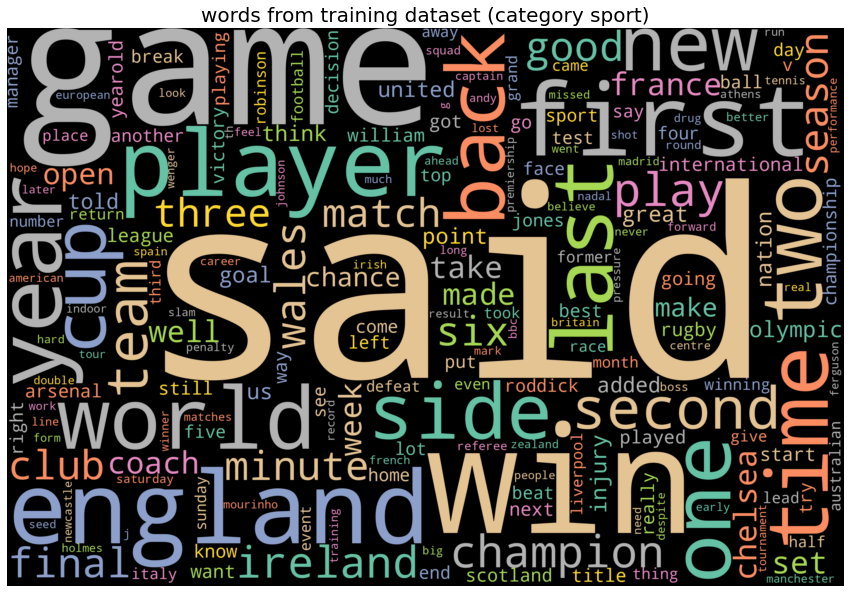

category entertainment, top 10 words: ['film', 'said', 'best', 'year', 'award', 'u', 'show', 'new', 'one', 'music']


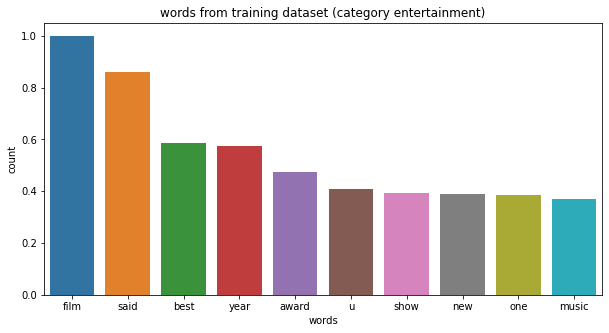

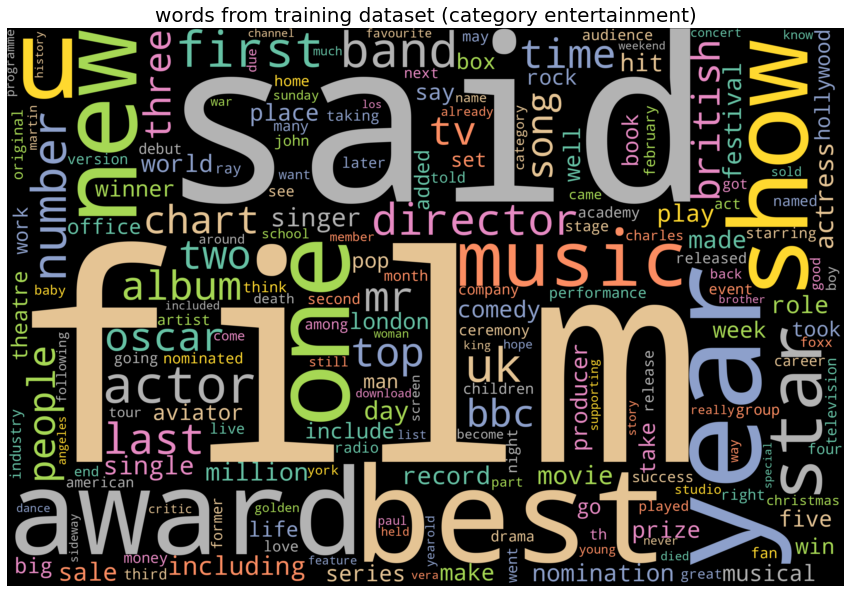

In [60]:
def plot_wordcloud(text, title, k=10):
  # Create and Generate a Word Cloud Image
  wordcloud = WordCloud(width = 3000, height = 2000, random_state=1, background_color='black', colormap='Set2', collocations=False, stopwords = STOPWORDS).generate(text)
  # top k words
  plt.figure(figsize=(10,5))
  print(f'category {cat}, top {k} words: {list(wordcloud.words_.keys())[:k]}')
  ax = sns.barplot(x=0, y=1, data=pd.DataFrame(wordcloud.words_.items()).head(k))
  ax.set(xlabel = 'words', ylabel='count', title=title)
  plt.show()
  #Display the generated image
  plt.figure(figsize=(15,15))
  plt.imshow(wordcloud, interpolation="bilinear"), plt.title(title, size=20), plt.axis("off")
  plt.show()

for cat in df_train['Category'].unique():
  plot_wordcloud(' '.join(df_train[df_train['Category']==cat]['Text'].values), f'words from training dataset (category {cat})')

Preprocess Labels in the training dataset to get a **OHE** (one-hot-encoding) of the labels from the training dataset.

In [155]:
le = LabelEncoder()
y_train = df_train['Category'].values
y_train = le.fit_transform(y_train)
y_train = to_categorical(y_train, num_classes=ncats)
X_train, X_test = df_train['Text'].values, df_test['Text'].values
y_train.shape, ncats

((1490, 5), 5)

## Model Architecture 

We shall use multiple models, starting from LSTM/GRU/BiLSTM to BERT and USE. 

## LSTM / GRU

Let's start with vanilla LSTM / GRU model. We need to start by tokenizing the texts followed adding appropriate pads to the token sequence (to have the seuqence length fixed, e.g. equal to `max_len`)

In [156]:
xtrain, xtest, ytrain, ytest = train_test_split(X_train, y_train, shuffle=True, test_size=0.2)

max_len = max(df_train['Text'].apply(lambda x: len(x.split())).values)
max_words = 20000
tokenizer = text.Tokenizer(num_words = max_words)
# create the vocabulary by fitting on x_train text
tokenizer.fit_on_texts(xtrain)
# generate the sequence of tokens
xtrain_seq = tokenizer.texts_to_sequences(xtrain)
xtest_seq = tokenizer.texts_to_sequences(xtest)

# pad the sequences
xtrain_pad = sequence.pad_sequences(xtrain_seq, maxlen=max_len)
xtest_pad = sequence.pad_sequences(xtest_seq, maxlen=max_len)
word_index = tokenizer.word_index

print('text example:', xtrain[0])
print('sequence of indices(before padding):', xtrain_seq[0])
print('sequence of indices(after padding):', xtrain_pad[0])

text example: prince crowned  top music earner  prince earned more than any other pop star in 2004  beating artists such madonna and elton john in us magazine rolling stone s annual list.  the singer banked $56.5m (£30.4m) from concerts  album and publishing sales with his musicology tour and album. he kept madonna in second place  as she earned $54.9m (£29.5m) while embarking on her global re-invention tour. veterans simon and garfunkel were in 10th place  their comeback tour helping them earn $24.9m (£13.4m) last year.   prince returned to centre stage after a decade in the commercial wilderness   the magazine reported. the singer s 2004 tour took $90.3m (£48.5m) in ticket sales and he sold 1.9 million copies of his latest album musicology.  although she grossed more than prince last year  madonna remained in second place because of the  monumental  production costs of her tour. heavy metal band metallica s madly in anger with the world tour helped push their 2004 earnings up to $43.

We shall first use a pretrained (semantic) embedding from *Global Vectors for Word Representation* (**GloVe**) model (dowload the pretrained weights) and create a word-level embedding matrix as shown below. Later we shall use `LSTM` to train the embedding on our own.

In [ ]:
#https://nlp.stanford.edu/projects/glove/
!wget https://nlp.stanford.edu/data/glove.6B.zip
!unzip g*zip

In [65]:
%%time
embedding_vectors = {}
with open('glove.6B.300d.txt','r',encoding='utf-8') as file: #glove.42B.300d.txt
    for row in file:
        values = row.split(' ')
        word = values[0]
        weights = np.asarray([float(val) for val in values[1:]])
        embedding_vectors[word] = weights
print(f"Size of vocabulary in GloVe: {len(embedding_vectors)}")  

Size of vocabulary in GloVe: 400000
CPU times: user 36.2 s, sys: 1.43 s, total: 37.7 s
Wall time: 36.9 s


In [157]:
#initialize the embedding_matrix with zeros
emb_dim = 300
vocab_len = max_words if max_words is not None else len(word_index)+1
embedding_matrix = np.zeros((vocab_len, emb_dim))
oov_count = 0
oov_words = []
for word, idx in word_index.items():
    if idx < vocab_len:
        embedding_vector = embedding_vectors.get(word)
        if embedding_vector is not None:
            embedding_matrix[idx] = embedding_vector
        else:
            oov_count += 1 
            oov_words.append(word)
#print some of the out of vocabulary words
print(f'Some out of valubulary words: {oov_words[0:5]}')
print(f'{oov_count} out of {vocab_len} words were OOV.')

Some out of valubulary words: ['£1', '5bn', '£2', '8bn', '6bn']
858 out of 20000 words were OOV.


Let's create the model with and `Embedding` layer followed by the `LSTM` layer and add a bunch of `Dense` layers on top. Here we shall first use pretrained GloVe embeddings by setting `trainable=False`.

In [176]:
model_lstm = Sequential(name='model_lstm')
model_lstm.add(Embedding(vocab_len, emb_dim, trainable = False, weights=[embedding_matrix]))
model_lstm.add(LSTM(64, activation='tanh', return_sequences=False))
model_lstm.add(Dense(128, activation='relu'))
#model_lstm.add(tf.keras.layers.BatchNormalization())
model_lstm.add(Dropout(0.2)) # Adding Dropout layer with rate of 0.2
model_lstm.add(Dense(256, activation='relu'))
model_lstm.add(Dense(128, activation='relu'))
model_lstm.add(Dense(64, activation='relu'))
model_lstm.add(Dense(ncats, activation='softmax'))
model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy', tf.keras.metrics.AUC()])
model_lstm.summary()

Model: "model_lstm"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_26 (Embedding)    (None, None, 300)         6000000   
                                                                 
 lstm_17 (LSTM)              (None, 64)                93440     
                                                                 
 dense_106 (Dense)           (None, 128)               8320      
                                                                 
 dropout_30 (Dropout)        (None, 128)               0         
                                                                 
 dense_107 (Dense)           (None, 256)               33024     
                                                                 
 dense_108 (Dense)           (None, 128)               32896     
                                                                 
 dense_109 (Dense)           (None, 64)                8

Now, let's create the model using `GRU` layer instead of LSTM, as shown in the following code snippet.

In [166]:
emb_dim = embedding_matrix.shape[1]
model_gru = Sequential(name='model_gru')
model_gru.add(Embedding(vocab_len, emb_dim, trainable = True))
model_gru.add(GRU(128, return_sequences=False))
model_gru.add(Dropout(0.5))
model_gru.add(Dense(ncats, activation = 'sigmoid'))
model_gru.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy', tf.keras.metrics.AUC()])
model_gru.summary()

Model: "model_gru"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_23 (Embedding)    (None, None, 300)         6000000   
                                                                 
 gru_7 (GRU)                 (None, 128)               165120    
                                                                 
 dropout_27 (Dropout)        (None, 128)               0         
                                                                 
 dense_95 (Dense)            (None, 5)                 645       
                                                                 
Total params: 6,165,765
Trainable params: 6,165,765
Non-trainable params: 0
_________________________________________________________________


## Universal Sequence Encoder Model (USE)

Finally, we shall use the *Universal Sentence Encoder* to obtain sentence level embedding, along with our regular `Dense` layers to create a binary text classification model.

In [145]:
transfer_model_url = 'https://tfhub.dev/google/universal-sentence-encoder-cmlm/en-base/1'
sentence_encoder_layer = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                                        input_shape=[],  # shape of inputs coming to our model
                                        dtype=tf.string,  # data type of inputs coming to the USE layer
                                        trainable=False,
                                        # keep the pretrained weights (we'll create a feature extractor)
                                        name="USE")

model_use = tf.keras.Sequential([
    sentence_encoder_layer,
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(5, activation="softmax")
], name = 'transfer_mode')
model_use.summary()

Model: "transfer_mode"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 USE (KerasLayer)            (None, 512)               256797824 
                                                                 
 dropout_21 (Dropout)        (None, 512)               0         
                                                                 
 dense_71 (Dense)            (None, 16)                8208      
                                                                 
 dense_72 (Dense)            (None, 16)                272       
                                                                 
 dense_73 (Dense)            (None, 5)                 85        
                                                                 
Total params: 256,806,389
Trainable params: 8,565
Non-trainable params: 256,797,824
_________________________________________________________________


## Results and Analysis

Let's now fit the models on the training dataset and compare the performance of the model (in terms of accuracy and ROC AUC) on the held-out validation daatset. The metric *Recall* is more important than *precision* / *accuracy* here becuase we shall like our model to capture as many of the true disaster tweets as possibile.

## LSTM / GRU

The LSTM model was trained for 10 epochs and obtained ~93% accuracy on validation dataset. The model was trained with pe-trained **GloVe** `Embedding` layers and then later the `Embedding` layer was trained from the data.

In [171]:
# with pretrained GloVe weights
%%time
batch_size = 32
epochs  = 10
history = model_lstm.fit(xtrain_pad, np.asarray(ytrain), validation_data=(xtest_pad, np.asarray(ytest)), batch_size = batch_size, epochs = epochs)

Epoch 1/10
38/38 [==============================] - 8s 114ms/step - loss: 1.4714 - accuracy: 0.3498 - auc_20: 0.6841 - val_loss: 0.9792 - val_accuracy: 0.6846 - val_auc_20: 0.8880
Epoch 2/10
38/38 [==============================] - 4s 114ms/step - loss: 0.7147 - accuracy: 0.7810 - auc_20: 0.9327 - val_loss: 0.7228 - val_accuracy: 0.7785 - val_auc_20: 0.9275
Epoch 3/10
38/38 [==============================] - 4s 99ms/step - loss: 0.3828 - accuracy: 0.8960 - auc_20: 0.9751 - val_loss: 0.3029 - val_accuracy: 0.9128 - val_auc_20: 0.9839
Epoch 4/10
38/38 [==============================] - 4s 106ms/step - loss: 0.5554 - accuracy: 0.8180 - auc_20: 0.9591 - val_loss: 0.5291 - val_accuracy: 0.7987 - val_auc_20: 0.9620
Epoch 5/10
38/38 [==============================] - 4s 109ms/step - loss: 0.3718 - accuracy: 0.8767 - auc_20: 0.9789 - val_loss: 0.4314 - val_accuracy: 0.8691 - val_auc_20: 0.9734
Epoch 6/10
38/38 [==============================] - 4s 105ms/step - loss: 0.3168 - accuracy: 0.9094 -

<Figure size 720x432 with 0 Axes>

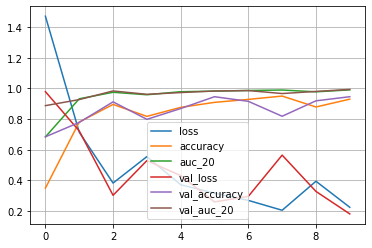

In [174]:
plt.figure(figsize=(10, 6))
pd.DataFrame(history.history).plot()
plt.grid()
plt.show()

The GRU model was trained for 10 epochs (this time the `Embedding` layer weights were trained rom the data) and obtained ~91% accuracy on validation dataset.

In [175]:
batch_size = 32
epochs  = 10
history = model_gru.fit(xtrain_pad, np.asarray(ytrain), validation_data=(xtest_pad, np.asarray(ytest)), batch_size = batch_size, epochs = epochs)

Epoch 1/10
38/38 [==============================] - 16s 315ms/step - loss: 1.5968 - accuracy: 0.2701 - auc_18: 0.5788 - val_loss: 1.5691 - val_accuracy: 0.3893 - val_auc_18: 0.6459
Epoch 2/10
38/38 [==============================] - 13s 354ms/step - loss: 1.3332 - accuracy: 0.5763 - auc_18: 0.8342 - val_loss: 1.0221 - val_accuracy: 0.6141 - val_auc_18: 0.8481
Epoch 3/10
38/38 [==============================] - 11s 283ms/step - loss: 0.5853 - accuracy: 0.8716 - auc_18: 0.9596 - val_loss: 0.7183 - val_accuracy: 0.7450 - val_auc_18: 0.9051
Epoch 4/10
38/38 [==============================] - 13s 350ms/step - loss: 0.1410 - accuracy: 0.9706 - auc_18: 0.9925 - val_loss: 0.8042 - val_accuracy: 0.7483 - val_auc_18: 0.9142
Epoch 5/10
38/38 [==============================] - 10s 266ms/step - loss: 0.0233 - accuracy: 0.9983 - auc_18: 0.9998 - val_loss: 0.6009 - val_accuracy: 0.8188 - val_auc_18: 0.9471
Epoch 6/10
38/38 [==============================] - 10s 257ms/step - loss: 0.0045 - accuracy: 1

## Model USE

Finally, the *Universal Sentence Embedding* model was trained, it outperformed all the models and obtained more than 80% public score on *Kaggle* on the test dataset.

In [146]:
X, y = df_train['Text'].values, df_train['Category'].values
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y, num_classes=ncats)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)
X.shape, y.shape

((1490,), (1490, 5))

In [147]:
model_use.compile(loss = tf.keras.losses.CategoricalCrossentropy(),
             optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
             metrics=['accuracy',tf.keras.metrics.AUC()])

In [148]:
%%time
history = model_use.fit(X_train, y_train, epochs = 10, validation_data=(X_val, y_val))

Epoch 1/10
35/35 [==============================] - 5s 63ms/step - loss: 1.5509 - accuracy: 0.2417 - auc_14: 0.6889 - val_loss: 1.4576 - val_accuracy: 0.2386 - val_auc_14: 0.7670
Epoch 2/10
35/35 [==============================] - 5s 140ms/step - loss: 1.3365 - accuracy: 0.4458 - auc_14: 0.8565 - val_loss: 1.1981 - val_accuracy: 0.6434 - val_auc_14: 0.9283
Epoch 3/10
35/35 [==============================] - 2s 52ms/step - loss: 1.0470 - accuracy: 0.8066 - auc_14: 0.9647 - val_loss: 0.8852 - val_accuracy: 0.8820 - val_auc_14: 0.9846
Epoch 4/10
35/35 [==============================] - 2s 48ms/step - loss: 0.7476 - accuracy: 0.9087 - auc_14: 0.9888 - val_loss: 0.6052 - val_accuracy: 0.9196 - val_auc_14: 0.9941
Epoch 5/10
35/35 [==============================] - 1s 41ms/step - loss: 0.5160 - accuracy: 0.9293 - auc_14: 0.9925 - val_loss: 0.4176 - val_accuracy: 0.9437 - val_auc_14: 0.9958
Epoch 6/10
35/35 [==============================] - 2s 49ms/step - loss: 0.3699 - accuracy: 0.9427 - auc

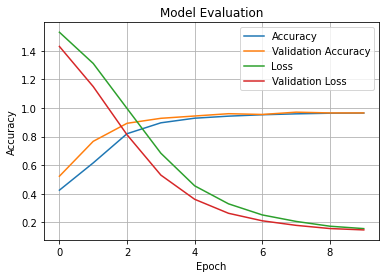

In [131]:
def plot_hist(hist):
    '''
    Plots the training / validation loss and accuracy given the training history
    '''
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history['val_accuracy'])
    plt.plot(hist.history['loss'])
    plt.plot(hist.history['val_loss'])
    plt.title("Model Evaluation")
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend(["Accuracy","Validation Accuracy","Loss","Validation Loss"])
    plt.grid()
    plt.show()
    
plot_hist(history)

### Prediction and Submission to Kaggle

In [149]:
X_test = df_test['Text'].values
predictions_prob = model_use.predict(X_test)
predictions = tf.argmax(predictions_prob, axis=1)
predictions = le.inverse_transform(predictions)

23/23 [==============================] - 1s 38ms/step


In [150]:
submission = pd.read_csv('BBC News Sample Solution.csv')
submission['Category'] = predictions
submission.to_csv('submission.csv', index=False)
submission.head()

,ArticleId,Category
0,1018,sport
1,1319,tech
2,1138,sport
3,459,business
4,1020,sport


## Conclusion 

The Sentence-level Embedding (USE) model performed the best on the test data (*Kaggle* public score ~81.1%), whereas *BiLSTM* and *BERT* models did decent jobs. Surprisingly, the USE model performed pretty well without any preprocessing. Training *BERT* for longer time may improve the accuracy of the transfomer on the test dataset. The next screenshots show the *Kaggle* public scores obtained for different submissions and the **leaderboard** position for the best sumission is **265**, as of now.

![](submission_.png)

![](leaderboard.png)

## Kaggle Competition: BBC News Classification 

This Kaggle competition is about categorizing news articles. You will use matrix factorization to predict the category and submit your notebook for peer evaluation. 

The part has 80 points. The instructions summarize the criteria you will use to guide your submission and review others’ submissions. 

You will submit one deliverable for Part 1: 

A Jupyter notebook with exploratory data analysis (EDA) procedure, model building and training, and comparison with supervised learning. 

Suppose your work becomes so large that it doesn’t fit into one notebook (or you think it will be less readable by having one large notebook). In that case, you can make several notebooks or scripts in a GitHub repository (as deliverable 3) and submit a report-style notebook or pdf instead.

# Part 1

## Exploratory Data analysis (EDA) 

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from time import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('learn-ai-bbc/BBC News Train.csv')
test = pd.read_csv('learn-ai-bbc/BBC News Test.csv')
sample_solution = pd.read_csv('learn-ai-bbc/BBC News Sample Solution.csv')

In [4]:
print(train.shape)
train.head()

(1490, 3)


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


As we can see there are 5 unique categories of news articles and the dataset is nearly balanced (at least not heavily imbalanced), each one category being roughly present with nearly equal proportion.

In [16]:
#print(train.info)
train.Category.value_counts()

sport            346
business         336
politics         274
entertainment    273
tech             261
Name: Category, dtype: int64

In [5]:
print(test.shape)
test.head()

(735, 2)


,ArticleId,Text
0,1018,qpr keeper day heads for preston queens park r...
1,1319,software watching while you work software that...
2,1138,d arcy injury adds to ireland woe gordon d arc...
3,459,india s reliance family feud heats up the ongo...
4,1020,boro suffer morrison injury blow middlesbrough...


In [18]:
def load_data_preprocess(train, test):
    t0 = time()
    vectorizer = TfidfVectorizer(sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english")
    X_train = vectorizer.fit_transform(train.Text.values)
    y_train = train.Category.values
    feature_names = vectorizer.get_feature_names_out()
    target_names = list(set(y_train))
    duration_train = time() - t0
    print('feature extraction time (train)',duration_train)
    # Extracting features from the test data using the same vectorizer
    t0 = time()
    X_test = vectorizer.transform(test.Text.values)
    duration_test = time() - t0
    print('feature extraction time (test)', duration_test)    
    return X_train, X_test, y_train, feature_names, target_names

X_train, X_test, y_train, feature_names, target_names = load_data_preprocess(train, test)
X_train.shape, y_train.shape, X_test.shape, len(feature_names), len(target_names)

feature extraction time (train) 0.5251326560974121
feature extraction time (test) 0.24383997917175293


((1490, 7113), (1490,), (735, 7113), 7113, 5)

## Supervised Model Building 

### Baseline Model

In [81]:
from sklearn.linear_model import RidgeClassifier

def train_predict(clf, X_train, y_train, X_test, output_file):

    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    pred_result = pd.DataFrame({'ArticleId': test.ArticleId.values, 'Category': pred})
    pred_result.to_csv(output_file, index=False)
    
train_predict(RidgeClassifier(tol=1e-2, solver="sparse_cg"), X_train, y_train, X_test, 
              output_file='learn-ai-bbc/BBC News Baseline Solution.csv') 

As can be seen from the next figure, the baseline model was submitted successfully to Kaggle, with score $~0.985$.

![](kaggle_submission.png)

## Visualizing the Decision Boundaries for Classification

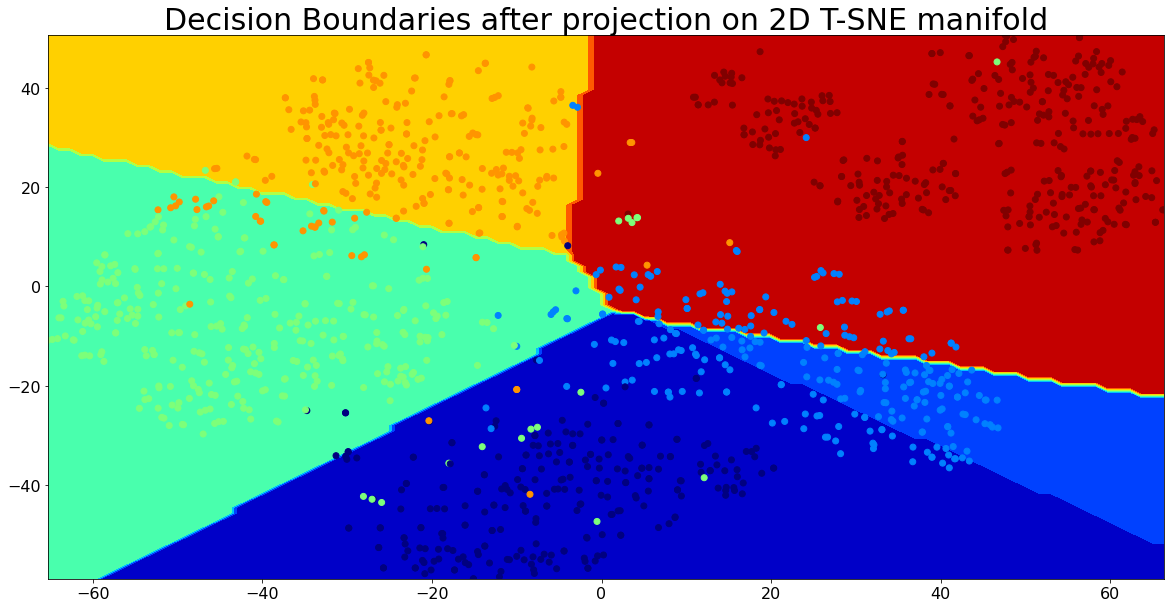

In [62]:
from sklearn.manifold import TSNE
X_train_embedding = TSNE(n_components=2).fit_transform(X_train)
resolution = 100 # 100x100 background pixels
X2d_xmin, X2d_xmax = np.min(X_train_embedding[:,0]), np.max(X_train_embedding[:,0])
X2d_ymin, X2d_ymax = np.min(X_train_embedding[:,1]), np.max(X_train_embedding[:,1])
xx, yy = np.meshgrid(np.linspace(X2d_xmin, X2d_xmax, resolution), np.linspace(X2d_ymin, X2d_ymax, resolution))
background_model = clf.fit(X_train_embedding, clf.predict(X_train)) 
vbg = background_model.predict(np.c_[xx.ravel(), yy.ravel()])
vbg = vbg.reshape((resolution, resolution))
colors = {name: color for (name, color) in zip(target_names, range(len(target_names)))}
plt.figure(figsize=(20,10))
plt.contourf(xx, yy, np.array([colors[x] for x in vbg.ravel()]).reshape(vbg.shape), cmap='jet')
plt.scatter(X_train_embedding[:,0], X_train_embedding[:,1], c=np.array([colors[y] for y in y_train]), cmap='jet')
plt.title('Decision Boundaries after projection on 2D T-SNE manifold', size=30)
plt.show()

## Model Selection and Model Evaluation

### With Cross Validation 

First let's start with the same baseline classifier and evaluate the performance on a random held-out validation dataset.

accuracy on validation:  0.9839142091152815


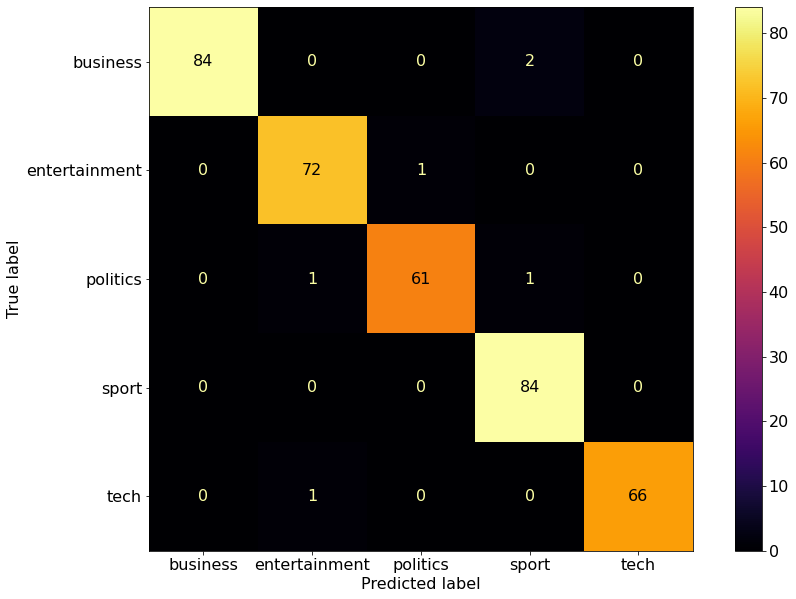

In [66]:
from sklearn.metrics import plot_confusion_matrix
X_train_, X_val, y_train_, y_val = train_test_split(X_train, y_train, random_state=0)
clf.fit(X_train_, y_train_)
print('accuracy on validation: ', clf.score(X_val, y_val))
fig, ax = plt.subplots(figsize=(15, 10))
plt.rcParams.update({'font.size': 16})
plot_confusion_matrix(clf, X_val, y_val, cmap='inferno', ax=ax)  
plt.show()

Now, let's try $k=5$ fold cross-validation and report the accuracies on the validation folds.

In [25]:
from sklearn.model_selection import cross_val_score
cross_val_score(estimator=clf, X=X_train, y=y_train, cv=5)

array([0.96979866, 0.96308725, 0.98657718, 0.98322148, 0.98322148])

## Hyperparameter Tuning With GridSearchCV

### RidgeClassifier Model

In [83]:
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

def tune_hyperparameters(clf, param_grid, X_train, y_train, X_val, y_val):
    
    grid = GridSearchCV(clf, param_grid, refit = True, verbose = 3, n_jobs=-1) 

    grid.fit(X_train, y_train) 

    print('Bets params:', grid.best_params_) 
    grid_pred = grid.predict(X_val) 

    print('val score:', grid.score(X_val, y_val))
    
    print(classification_report(y_val, grid_pred))     

tune_hyperparameters(RidgeClassifier(tol=1e-2, solver="sparse_cg"), 
                     {'alpha': [1, 0.1, 0.01, 0.001, 0.0001, 0]}, 
                     X_train_, y_train_, X_val, y_val)  

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Bets params: {'alpha': 1}
val score: 0.9839142091152815
               precision    recall  f1-score   support

     business       1.00      0.98      0.99        86
entertainment       0.97      0.99      0.98        73
     politics       0.98      0.97      0.98        63
        sport       0.97      1.00      0.98        84
         tech       1.00      0.99      0.99        67

     accuracy                           0.98       373
    macro avg       0.98      0.98      0.98       373
 weighted avg       0.98      0.98      0.98       373



In [84]:
train_predict(RidgeClassifier(tol=1e-2, alpha=1, solver="sparse_cg"), X_train, y_train, X_test, 
              output_file='learn-ai-bbc/BBC RidgeClassifier Solution.csv') 

### Support Vector Classfier Model

In [69]:
from sklearn.svm import SVC    
tune_hyperparameters(SVC(), 
                     {'C': [0.1, 1, 10, 100],  
                      'gamma':['scale', 'auto'],
                      'kernel': ['linear', 'rbf']}, 
                      X_train_, y_train_, X_val, y_val)  

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Bets params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
               precision    recall  f1-score   support

     business       0.99      0.98      0.98        86
entertainment       0.96      0.99      0.97        73
     politics       0.97      0.95      0.96        63
        sport       0.99      0.99      0.99        84
         tech       0.99      0.99      0.99        67

     accuracy                           0.98       373
    macro avg       0.98      0.98      0.98       373
 weighted avg       0.98      0.98      0.98       373



Now, let's train the SVC model with the best hyperparameters obtained, this time on the entire training dataset and then make a prediction on the unseen test dataset, so that we shall be ready for another submission. 

In [85]:
train_predict(SVC(C=10, gamma='scale', kernel="linear"), X_train, y_train, X_test, 
              output_file='learn-ai-bbc/BBC News SVC Solution.csv') 

As can be seen, the accuracy score on the unseen test dataset increased slightly after this submission.

![](kaggle_submission2.png)

### Random Forest Ensemble Classifier Model

In [72]:
from sklearn.ensemble import RandomForestClassifier
tune_hyperparameters(RandomForestClassifier(random_state=0), 
                     {
                            'n_estimators': [100, 500],
                            'criterion': ['gini', 'entropy'],
                            'bootstrap': [True, False]
                      }, 
                      X_train_, y_train_, X_val, y_val)  

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Bets params: {'bootstrap': False, 'criterion': 'gini', 'n_estimators': 500}
               precision    recall  f1-score   support

     business       0.98      0.97      0.97        86
entertainment       0.96      0.97      0.97        73
     politics       0.97      0.97      0.97        63
        sport       0.95      0.99      0.97        84
         tech       0.97      0.93      0.95        67

     accuracy                           0.97       373
    macro avg       0.97      0.96      0.96       373
 weighted avg       0.97      0.97      0.97       373



Although the performance of RF is slightly worse than the above classifiers, still submitting it to check if it removes any possible overfitting earlier.

In [87]:
train_predict(RandomForestClassifier(n_estimators=500, criterion='gini', bootstrap=False), X_train, y_train, X_test, 
              output_file='learn-ai-bbc/BBC News RandomForest Solution.csv') 

As can be seen, the accuracy score on the unseen test dataset decreased with this submission, i.e., RF model trained did not generalize that well.

![](kaggle_submission3.png)

### Gradient Boosting Ensemble Classifier Model

In [73]:
from sklearn.ensemble import GradientBoostingClassifier
tune_hyperparameters(GradientBoostingClassifier(random_state=0), 
                    {
                    "learning_rate": [0.01, 0.1],
                    "min_samples_split": [0.1, 0.5],
                    "max_depth":[3,5],
                    "criterion": ["friedman_mse"],
                    "subsample":[0.5, 0.8],
                    "n_estimators":[10]
                    }, 
                    X_train_, y_train_, X_val, y_val)  

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Bets params: {'criterion': 'friedman_mse', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 0.1, 'n_estimators': 10, 'subsample': 0.5}
               precision    recall  f1-score   support

     business       0.95      0.91      0.93        86
entertainment       0.93      0.90      0.92        73
     politics       0.91      0.94      0.92        63
        sport       0.89      1.00      0.94        84
         tech       0.97      0.88      0.92        67

     accuracy                           0.93       373
    macro avg       0.93      0.93      0.93       373
 weighted avg       0.93      0.93      0.93       373



In [88]:
train_predict(GradientBoostingClassifier(criterion='friedman_mse', learning_rate=0.1, max_depth=5, 
              min_samples_split=0.1, n_estimators=10, subsample=0.5, random_state=0), 
              X_train, y_train, X_test, 
              output_file='learn-ai-bbc/BBC News GBM Solution.csv') 

As can be seen, the accuracy score on the unseen test dataset had falled significantly with this submission, i.e., GBM model trained overfitted on the training dataset more than other models.

![](kaggle_submission4.png)

### Stacked Ensemble Classifier Model

Finaly, let's try a Stacked Ensemble model by combining the predictions of the different classifiers tried earlier with the best hyperparameter values obtained.

In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
estimators = [
        ('rc', RidgeClassifier(alpha=1)),
        ('rfc', RandomForestClassifier(n_estimators=500, bootstrap=False, criterion='gini', random_state=0)),
        ('svc', SVC(C=10, gamma='scale', kernel='linear', random_state=0)),
        #('svc', make_pipeline(StandardScaler(), SVC(C=10, gamma='scale', kernel='linear', random_state=0))),
        ('gbc', GradientBoostingClassifier(criterion='friedman_mse', learning_rate=0.1, max_depth=5, 
                                           min_samples_split=0.1, n_estimators=10, subsample=0.5, random_state=0))
]
clf = StackingClassifier(
    estimators=estimators, final_estimator=LogisticRegression()
)
clf.fit(X_train_, y_train_).score(X_val, y_val)

0.9785522788203753

In [91]:
train_predict(clf, 
              X_train, y_train, X_test, 
              output_file='learn-ai-bbc/BBC News StackedEnsemble Solution.csv') 

As can be seen, the accuracy score on the unseen test dataset increased again with this submission.

![](kaggle_submission5.png)

In [ ]:
# Unsupervised Model Building

## Conclusion

As ca be seen from the above result, the Linear Support Vector Classifier model and the Stacked Ensemble Classifier performed based on the unseen dataset.